# Supporting Figures

This notebook generates the Supporting Information figures for the hydrovoltaic-ML manuscript.

Design rules:
1. Supporting figures should not duplicate main-text figures.
2. All plots use the same visual style as the main-text figures via `src/paper_style.py`.
3. Combined supplementary figures are generated for SI use.
4. Existing analysis notebooks are not modified.
5. Figures are generated from saved CSV outputs whenever possible.

Planned supporting figures:
- Fig. S1. Target construction and reported-power consistency
- Fig. S2. Model validation and robustness diagnostics
- Fig. S3. Resistance-regime threshold sensitivity
- Fig. S4. Extended internal-resistance origin analysis
- Fig. S5. Full virtual-design landscape

In [32]:
from pathlib import Path
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Run this notebook from:
# hydrovoltaic-ml/notebooks/

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

SI_DIR = RESULTS_DIR / "supporting_materials"
SI_FIG_DIR = SI_DIR / "figures"

SI_FIG_DIR.mkdir(parents=True, exist_ok=True)

for fig_id in ["Fig_S1", "Fig_S2", "Fig_S3", "Fig_S4", "Fig_S5"]:
    (SI_FIG_DIR / fig_id).mkdir(parents=True, exist_ok=True)

# Import shared paper style
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from paper_style import *

set_paper_style()

print("Project root:", PROJECT_ROOT)
print("Source folder:", SRC_DIR)
print("Results folder:", RESULTS_DIR)
print("SI figure folder:", SI_FIG_DIR)
print("Generated:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Project root: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml
Source folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\src
Results folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results
SI figure folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\supporting_materials\figures
Generated: 2026-05-27 13:50:03


In [33]:
def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return path


def read_csv_safe(path):
    path = require_file(path)
    return pd.read_csv(path, encoding="utf-8-sig")


def pick_col(df, candidates, contains=None):
    """
    Pick the first matching column from a dataframe.
    """
    if df is None:
        return None

    for c in candidates:
        if c in df.columns:
            return c

    if contains is not None:
        for c in df.columns:
            cl = c.lower()
            if all(s.lower() in cl for s in contains):
                return c

    return None


def clean_label_for_plot(x):
    """
    Convert technical labels to readable plot labels.
    """
    if pd.isna(x):
        return ""

    x = str(x)
    x = x.replace("_", " ")
    x = x.replace("log R", "log(R)")
    x = x.replace("log P est", "log(P_est)")
    x = x.replace("P est", "P_est")
    return x


def save_combined_figure(fig, fig_id, filename_stem):
    """
    Save combined SI figure as PDF, SVG, and PNG.
    """
    out_dir = SI_FIG_DIR / fig_id
    out_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for ext in ["pdf", "svg", "png"]:
        out_path = out_dir / f"{filename_stem}.{ext}"
        fig.savefig(out_path, bbox_inches="tight", pad_inches=0.03, dpi=600)
        saved_paths.append(out_path)

    print("Saved:")
    for p in saved_paths:
        print(" -", p.relative_to(PROJECT_ROOT))

    return saved_paths


def add_panel_label(ax, label):
    """
    Add panel label such as A, B, C.
    """
    ax.text(
        -0.12,
        1.08,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
        color=COLORS.get("black", "black"),
    )

In [34]:
SOURCE_FILES = {
    # Main Figure 1 related source files
    "fig1_logP_histogram": RESULTS_DIR / "figure1_dataset_overview" / "fig1C_log_P_est_histogram_bins.csv",
    "fig1_reporting_completeness": RESULTS_DIR / "figure1_dataset_overview" / "fig1D_reporting_completeness.csv",

    # Main Figure 3 related source files
    "fig3_model_comparison": RESULTS_DIR / "figure3_model_comparison" / "fig3A_tuned_model_comparison.csv",
    "fig3_descriptor_augmentation": RESULTS_DIR / "figure3_model_comparison" / "fig3B_modelA_modelB_descriptor_augmentation.csv",
    "fig3_ablation": RESULTS_DIR / "figure3_model_comparison" / "fig3C_feature_block_ablation.csv",
    "fig3_shap": RESULTS_DIR / "figure3_model_comparison" / "fig3D_SHAP_descriptor_importance.csv",

    # Main Figure 4 related source files
    "fig4_logR_raw": RESULTS_DIR / "figure4_resistance_regimes" / "fig4A_logR_vs_logPest_raw.csv",
    "fig4_logR_binned": RESULTS_DIR / "figure4_resistance_regimes" / "fig4A_logR_vs_logPest_binned_trend.csv",
    "fig4_regime_raw": RESULTS_DIR / "figure4_resistance_regimes" / "fig4B_R_regime_raw.csv",
    "fig4_regime_summary": RESULTS_DIR / "figure4_resistance_regimes" / "fig4B_R_regime_summary.csv",
    "fig4_R_descriptor_comparison": RESULTS_DIR / "figure4_resistance_regimes" / "fig4D_physics_aware_R_descriptor_comparison.csv",

    # Main Figure 5 related source files
    "fig5_raw_R_data": RESULTS_DIR / "figure5_R_origin" / "fig5_raw_observed_R_data.csv",
    "fig5_tests": RESULTS_DIR / "figure5_R_origin" / "fig5_statistical_tests.csv",

    # Main Figure 6 related source files
    "fig6_coefficients": RESULTS_DIR / "figure6_virtual_design" / "fig6A_linear_descriptor_coefficients_plot.csv",
    "fig6_model_comparison": RESULTS_DIR / "figure6_virtual_design" / "fig6B_linear_vs_polynomial_model_comparison.csv",
    "fig6_virtual_design": RESULTS_DIR / "figure6_virtual_design" / "fig6C_regime_aware_virtual_design.csv",
    "fig6_top_candidates": RESULTS_DIR / "figure6_virtual_design" / "fig6D_top_virtual_design_candidates.csv",
}

In [35]:
source_check = []

for key, path in SOURCE_FILES.items():
    exists = Path(path).exists()
    source_check.append(
        {
            "key": key,
            "exists": exists,
            "path": str(Path(path).relative_to(PROJECT_ROOT)) if exists else str(path),
        }
    )

source_check_df = pd.DataFrame(source_check)
display(source_check_df)

missing_source_df = source_check_df.loc[~source_check_df["exists"]].copy()

if len(missing_source_df) == 0:
    print("All registered source files were found.")
else:
    print("Missing registered source files:")
    display(missing_source_df)

,key,exists,path
0,fig1_logP_histogram,True,results\figure1_dataset_overview\fig1C_log_P_e...
1,fig1_reporting_completeness,True,results\figure1_dataset_overview\fig1D_reporti...
2,fig3_model_comparison,True,results\figure3_model_comparison\fig3A_tuned_m...
3,fig3_descriptor_augmentation,True,results\figure3_model_comparison\fig3B_modelA_...
4,fig3_ablation,True,results\figure3_model_comparison\fig3C_feature...
5,fig3_shap,True,results\figure3_model_comparison\fig3D_SHAP_de...
6,fig4_logR_raw,True,results\figure4_resistance_regimes\fig4A_logR_...
7,fig4_logR_binned,True,results\figure4_resistance_regimes\fig4A_logR_...
8,fig4_regime_raw,True,results\figure4_resistance_regimes\fig4B_R_reg...
9,fig4_regime_summary,True,results\figure4_resistance_regimes\fig4B_R_reg...


All registered source files were found.


In [36]:
source_data = {}

for key, path in SOURCE_FILES.items():
    path = Path(path)

    if path.exists():
        source_data[key] = pd.read_csv(path, encoding="utf-8-sig")
    else:
        source_data[key] = None

print("Loaded registered source data:")
for key, df in source_data.items():
    if df is not None:
        print(f"{key:35s}", df.shape)
    else:
        print(f"{key:35s}", "None")

Loaded registered source data:
fig1_logP_histogram                 (15, 4)
fig1_reporting_completeness         (8, 5)
fig3_model_comparison               (4, 3)
fig3_descriptor_augmentation        (4, 4)
fig3_ablation                       (5, 5)
fig3_shap                           (10, 2)
fig4_logR_raw                       (112, 3)
fig4_logR_binned                    (5, 9)
fig4_regime_raw                     (112, 3)
fig4_regime_summary                 (2, 7)
fig4_R_descriptor_comparison        (3, 5)
fig5_raw_R_data                     (112, 4)
fig5_tests                          (3, 5)
fig6_coefficients                   (10, 4)
fig6_model_comparison               (2, 11)
fig6_virtual_design                 (15, 5)
fig6_top_candidates                 (10, 6)


In [37]:
# Search project for CSV files that may contain dataset-level records

candidate_records = []

search_roots = [
    DATA_DIR,
    RESULTS_DIR,
    NOTEBOOK_DIR,
]

for root in search_roots:
    if not root.exists():
        continue

    for p in root.rglob("*.csv"):
        try:
            df_tmp = pd.read_csv(p, encoding="utf-8-sig", nrows=5)
            cols = list(df_tmp.columns)

            lower_cols = [c.lower() for c in cols]

            has_voc = any(("voc" in c or "open" in c and "voltage" in c) for c in lower_cols)
            has_jsc = any(("jsc" in c or "short" in c and "current" in c) for c in lower_cols)
            has_power = any(("power" in c) for c in lower_cols)
            has_resistance = any(("resistance" in c or "log_r" in c or "logr" in c) for c in lower_cols)
            has_mechanism = any(("mechanism" in c) for c in lower_cols)
            has_structure = any(("structure" in c) for c in lower_cols)
            has_ion = any(("ion" in c) for c in lower_cols)

            score = sum([
                has_voc,
                has_jsc,
                has_power,
                has_resistance,
                has_mechanism,
                has_structure,
                has_ion,
            ])

            candidate_records.append(
                {
                    "relative_path": str(p.relative_to(PROJECT_ROOT)),
                    "n_columns_preview": len(cols),
                    "has_voc": has_voc,
                    "has_jsc": has_jsc,
                    "has_power": has_power,
                    "has_resistance": has_resistance,
                    "has_mechanism": has_mechanism,
                    "has_structure": has_structure,
                    "has_ion": has_ion,
                    "score": score,
                    "columns_preview": "; ".join(cols[:12]),
                }
            )

        except Exception as e:
            continue

dataset_candidates_df = pd.DataFrame(candidate_records)

dataset_candidates_df = dataset_candidates_df.sort_values(
    ["score", "relative_path"],
    ascending=[False, True],
).reset_index(drop=True)

display(dataset_candidates_df.head(30))

,relative_path,n_columns_preview,has_voc,has_jsc,has_power,has_resistance,has_mechanism,has_structure,has_ion,score,columns_preview
0,data\processed\hydrovoltaic_dataset_phase2_inp...,52,True,True,True,True,True,True,True,7,paper_doi; review_covered; ref_year; device_st...
1,notebooks\hydrovoltaic_clean.csv,46,True,True,True,True,True,True,True,7,paper_doi; review_covered; ref_year; device_st...
2,notebooks\hydrovoltaic_clean_phase1.csv,50,True,True,True,True,True,True,True,7,paper_doi; review_covered; ref_year; device_st...
3,notebooks\hydrovoltaic_dataset_phase2_input_ut...,52,True,True,True,True,True,True,True,7,paper_doi; review_covered; ref_year; device_st...
4,results\10_virtual_design_cases.csv,4,False,False,True,True,False,True,False,3,design_case; structure_class; log_internal_res...
5,results\figure5_R_origin\fig5_raw_observed_R_d...,4,False,False,False,True,False,True,True,3,log_R; inorganic_electrolyte_group; ion_type_c...
6,results\figure6_virtual_design\fig6C_virtual_d...,5,False,False,False,True,False,True,True,3,structure_clean; ion_type_clean; inorganic_ele...
7,results\figure6_virtual_design\fig6D_top_virtu...,6,False,False,False,True,False,True,True,3,structure_clean; ion_type_clean; inorganic_ele...
8,results\figure6_virtual_design\fig6D_virtual_d...,6,False,False,False,True,False,True,True,3,structure_clean; ion_type_clean; inorganic_ele...
9,results\supporting_materials\tables\Table_S8C_...,7,False,False,False,True,False,True,True,3,rank; structure_clean; ion_type_clean; inorgan...


In [38]:
if len(dataset_candidates_df) > 0:
    best_candidate_path = PROJECT_ROOT / dataset_candidates_df.loc[0, "relative_path"]
    print("Best candidate:")
    print(best_candidate_path)

    best_candidate_df = pd.read_csv(best_candidate_path, encoding="utf-8-sig")
    print("Shape:", best_candidate_df.shape)
    display(best_candidate_df.head())
    print("Columns:")
    for c in best_candidate_df.columns:
        print(" -", c)
else:
    print("No dataset candidate found.")

Best candidate:
C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\data\processed\hydrovoltaic_dataset_phase2_input_utf8.csv
Shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,...,ion_type,mechanism_simple,asym_env,asym_chem,asym_electrode,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,...,anion,streaming,1,0,0,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,...,anion,streaming,1,1,0,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0


Columns:
 - paper_doi
 - review_covered
 - ref_year
 - device_structure
 - built_in_asymmetry
 - asymmetry_origin
 - primary_mobile_ion
 - secondary_ion_present
 - secondary_mobile_ion
 - ion_origin
 - auxiliary_redox_present
 - continuous_output
 - water_interaction_mode
 - rh_percent
 - inorganic_electrolyte_present
 - inorganic_electrolyte_type
 - inorganic_electrolyte_concentration_wt%
 - polyelectrolyte_present
 - active_material_raw
 - material_class
 - structure_class
 - ionic_groups
 - top_electrode
 - bottom_electrode
 - electrode_symmetry
 - metal_electrode
 - voc_V
 - jsc_uA_cm2
 - power_density_uW_cm2
 - internal_resistance_Mohm
 - output_timescale_class
 - stability_time_min
 - dominant_mechanism
 - has_anionic
 - has_cationic
 - has_zwitterionic
 - polyelectrolyte_anionic_raw
 - polyelectrolyte_cationic_raw
 - polyelectrolyte_zwitterionic_raw
 - has_any_polyelectrolyte
 - estimated_power_density_uW_cm2
 - log_estimated_power_density
 - ion_type
 - mechanism_simple
 - asym

In [40]:
# ============================================================
# Select final dataset-level CSV for supporting figures
# Robust version: use dataset_candidates_df from Cell 7
# ============================================================

# Prefer the processed dataset if available
preferred_keyword = "hydrovoltaic_dataset_phase2_input_units_fixed.csv"

candidate_rows = dataset_candidates_df[
    dataset_candidates_df["relative_path"].str.contains(
        preferred_keyword,
        case=False,
        regex=False,
        na=False,
    )
].copy()

if len(candidate_rows) == 0:
    # fallback: use the highest-scoring candidate
    selected_relative_path = dataset_candidates_df.loc[0, "relative_path"]
else:
    # Prefer data/processed version over notebooks copy
    candidate_rows["is_processed"] = candidate_rows["relative_path"].str.contains(
        "data",
        case=False,
        regex=False,
        na=False,
    )
    candidate_rows = candidate_rows.sort_values(
        ["is_processed", "score"],
        ascending=[False, False],
    )
    selected_relative_path = candidate_rows.iloc[0]["relative_path"]

# Convert Windows-style backslashes to the current OS path format
selected_relative_path = str(selected_relative_path).replace("\\", "/")

DATASET_PATH = PROJECT_ROOT / selected_relative_path

print("Selected dataset path:")
print(DATASET_PATH)

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        "Selected dataset file was not found. "
        "Check whether the file exists at this path:\n"
        f"{DATASET_PATH}"
    )

df_full = read_csv_safe(DATASET_PATH)

print("\nLoaded final dataset:")
print(DATASET_PATH.relative_to(PROJECT_ROOT))
print("Shape:", df_full.shape)

display(df_full.head())

print("\nColumns:")
for c in df_full.columns:
    print(" -", c)

Selected dataset path:
C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\data\processed\hydrovoltaic_dataset_phase2_input_utf8.csv

Loaded final dataset:
data\processed\hydrovoltaic_dataset_phase2_input_utf8.csv
Shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,...,ion_type,mechanism_simple,asym_env,asym_chem,asym_electrode,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,...,anion,streaming,1,0,0,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,...,anion,streaming,1,1,0,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0



Columns:
 - paper_doi
 - review_covered
 - ref_year
 - device_structure
 - built_in_asymmetry
 - asymmetry_origin
 - primary_mobile_ion
 - secondary_ion_present
 - secondary_mobile_ion
 - ion_origin
 - auxiliary_redox_present
 - continuous_output
 - water_interaction_mode
 - rh_percent
 - inorganic_electrolyte_present
 - inorganic_electrolyte_type
 - inorganic_electrolyte_concentration_wt%
 - polyelectrolyte_present
 - active_material_raw
 - material_class
 - structure_class
 - ionic_groups
 - top_electrode
 - bottom_electrode
 - electrode_symmetry
 - metal_electrode
 - voc_V
 - jsc_uA_cm2
 - power_density_uW_cm2
 - internal_resistance_Mohm
 - output_timescale_class
 - stability_time_min
 - dominant_mechanism
 - has_anionic
 - has_cationic
 - has_zwitterionic
 - polyelectrolyte_anionic_raw
 - polyelectrolyte_cationic_raw
 - polyelectrolyte_zwitterionic_raw
 - has_any_polyelectrolyte
 - estimated_power_density_uW_cm2
 - log_estimated_power_density
 - ion_type
 - mechanism_simple
 - asy

In [41]:
# ============================================================
# Identify key columns for Fig. S1
# Target construction and reported-power consistency
# ============================================================

def find_col_by_keywords(df, keyword_groups, exclude_keywords=None):
    """
    Find a column whose lower-case name contains all keywords in at least one keyword group.
    
    keyword_groups:
        list of list, e.g. [["voc"], ["open", "voltage"]]
    exclude_keywords:
        list of strings that should not appear in the column name
    """
    exclude_keywords = exclude_keywords or []

    cols = list(df.columns)
    lower_map = {c: c.lower() for c in cols}

    for keywords in keyword_groups:
        for c in cols:
            cl = lower_map[c]
            if all(k.lower() in cl for k in keywords) and not any(e.lower() in cl for e in exclude_keywords):
                return c

    return None


col_voc = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["voc"],
        ["v_oc"],
        ["open", "voltage"],
    ],
)

col_jsc = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["jsc"],
        ["j_sc"],
        ["short", "current"],
    ],
)

col_reported_power = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["reported", "power"],
        ["power_density"],
        ["power", "density"],
    ],
    exclude_keywords=["estimated", "est", "log"],
)

col_estimated_power = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["estimated", "power"],
        ["p_est"],
        ["power_est"],
    ],
    exclude_keywords=["log"],
)

col_log_p_est = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["log", "estimated", "power"],
        ["log", "p_est"],
        ["log_p"],
    ],
)

col_mechanism = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["mechanism_simple"],
        ["mechanism"],
    ],
)

col_structure = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["structure_class"],
        ["structure"],
    ],
)

col_ion = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["ion_type"],
        ["primary", "ion"],
        ["ion"],
    ],
)

key_cols = {
    "Voc": col_voc,
    "Jsc": col_jsc,
    "reported_power": col_reported_power,
    "estimated_power": col_estimated_power,
    "log_P_est": col_log_p_est,
    "mechanism": col_mechanism,
    "structure": col_structure,
    "ion": col_ion,
}

print("Identified key columns:")
for k, v in key_cols.items():
    print(f"{k:20s}: {v}")

missing_required = [k for k in ["Voc", "Jsc"] if key_cols[k] is None]

if len(missing_required) > 0:
    raise ValueError(f"Missing required columns: {missing_required}")

print("\nColumn identification completed.")

Identified key columns:
Voc                 : voc_V
Jsc                 : jsc_uA_cm2
reported_power      : power_density_uW_cm2
estimated_power     : estimated_power_density_uW_cm2
log_P_est           : log_estimated_power_density
mechanism           : mechanism_simple
structure           : structure_class
ion                 : ion_type

Column identification completed.


In [42]:
# ============================================================
# Build plotting dataframe for Fig. S1
# ============================================================

figS1_df = pd.DataFrame()

# Required columns
figS1_df["Voc_V"] = pd.to_numeric(df_full[col_voc], errors="coerce")
figS1_df["Jsc_uA_cm2"] = pd.to_numeric(df_full[col_jsc], errors="coerce")

# Optional reported power
if col_reported_power is not None:
    figS1_df["P_reported_uW_cm2"] = pd.to_numeric(df_full[col_reported_power], errors="coerce")
else:
    figS1_df["P_reported_uW_cm2"] = np.nan

# Estimated power
if col_estimated_power is not None:
    figS1_df["P_est_uW_cm2"] = pd.to_numeric(df_full[col_estimated_power], errors="coerce")
else:
    # Compute from Voc and Jsc.
    # Voc [V] × Jsc [uA cm−2] gives uW cm−2.
    figS1_df["P_est_uW_cm2"] = figS1_df["Voc_V"] * figS1_df["Jsc_uA_cm2"] / 4

# log(P_est)
if col_log_p_est is not None:
    figS1_df["log_P_est"] = pd.to_numeric(df_full[col_log_p_est], errors="coerce")
else:
    figS1_df["log_P_est"] = np.log10(figS1_df["P_est_uW_cm2"].where(figS1_df["P_est_uW_cm2"] > 0))

# log reported power
figS1_df["log_P_reported"] = np.log10(
    figS1_df["P_reported_uW_cm2"].where(figS1_df["P_reported_uW_cm2"] > 0)
)

# log Voc and log Jsc
figS1_df["log_Voc"] = np.log10(figS1_df["Voc_V"].where(figS1_df["Voc_V"] > 0))
figS1_df["log_Jsc"] = np.log10(figS1_df["Jsc_uA_cm2"].where(figS1_df["Jsc_uA_cm2"] > 0))

# Optional categorical descriptors
if col_mechanism is not None:
    figS1_df["mechanism"] = df_full[col_mechanism].astype(str)
else:
    figS1_df["mechanism"] = "unknown"

if col_structure is not None:
    figS1_df["structure"] = df_full[col_structure].astype(str)
else:
    figS1_df["structure"] = "unknown"

if col_ion is not None:
    figS1_df["ion"] = df_full[col_ion].astype(str)
else:
    figS1_df["ion"] = "unknown"

# Difference between estimated and reported power
figS1_df["delta_logP_est_minus_reported"] = (
    figS1_df["log_P_est"] - figS1_df["log_P_reported"]
)

# Useful subsets
figS1_both_power = figS1_df.dropna(subset=["log_P_est", "log_P_reported"]).copy()
figS1_vj = figS1_df.dropna(subset=["log_Voc", "log_Jsc", "log_P_est"]).copy()

print("Fig. S1 plotting dataframe:")
print("Total rows:", len(figS1_df))
print("Rows with both estimated and reported power:", len(figS1_both_power))
print("Rows with Voc, Jsc, and log(P_est):", len(figS1_vj))

display(figS1_df.head())

# Save the plotting dataframe for reproducibility
figS1_out_csv = SI_FIG_DIR / "Fig_S1" / "Fig_S1_target_construction_plotting_data.csv"
figS1_df.to_csv(figS1_out_csv, index=False, encoding="utf-8-sig")

print("Saved plotting data:")
print(figS1_out_csv.relative_to(PROJECT_ROOT))

Fig. S1 plotting dataframe:
Total rows: 159
Rows with both estimated and reported power: 108
Rows with Voc, Jsc, and log(P_est): 159


,Voc_V,Jsc_uA_cm2,P_reported_uW_cm2,P_est_uW_cm2,log_P_est,log_P_reported,log_Voc,log_Jsc,mechanism,structure,ion,delta_logP_est_minus_reported
0,1.00,0.0150,0.0053,0.003750,-2.425853,-2.275724,0.000000,-1.823909,streaming,porous,proton,-0.150129
1,0.40,0.0200,0.0020,0.002000,-2.698753,-2.698970,-0.397940,-1.698970,streaming,porous,anion,0.000217
2,1.50,0.0250,0.0094,0.009375,-2.027982,-2.026872,0.176091,-1.602060,streaming,porous,anion,-0.001110
3,0.85,0.0368,NaN,0.007820,-2.106738,NaN,-0.070581,-1.434152,streaming,porous,proton,NaN
4,0.16,0.0400,NaN,0.001600,-2.795609,NaN,-0.795880,-1.397940,streaming,porous,proton,NaN


Saved plotting data:
results\supporting_materials\figures\Fig_S1\Fig_S1_target_construction_plotting_data.csv


Saved:
 - results\supporting_materials\figures\Fig_S1\Fig_S1_target_construction_reported_power_consistency.pdf
 - results\supporting_materials\figures\Fig_S1\Fig_S1_target_construction_reported_power_consistency.svg
 - results\supporting_materials\figures\Fig_S1\Fig_S1_target_construction_reported_power_consistency.png


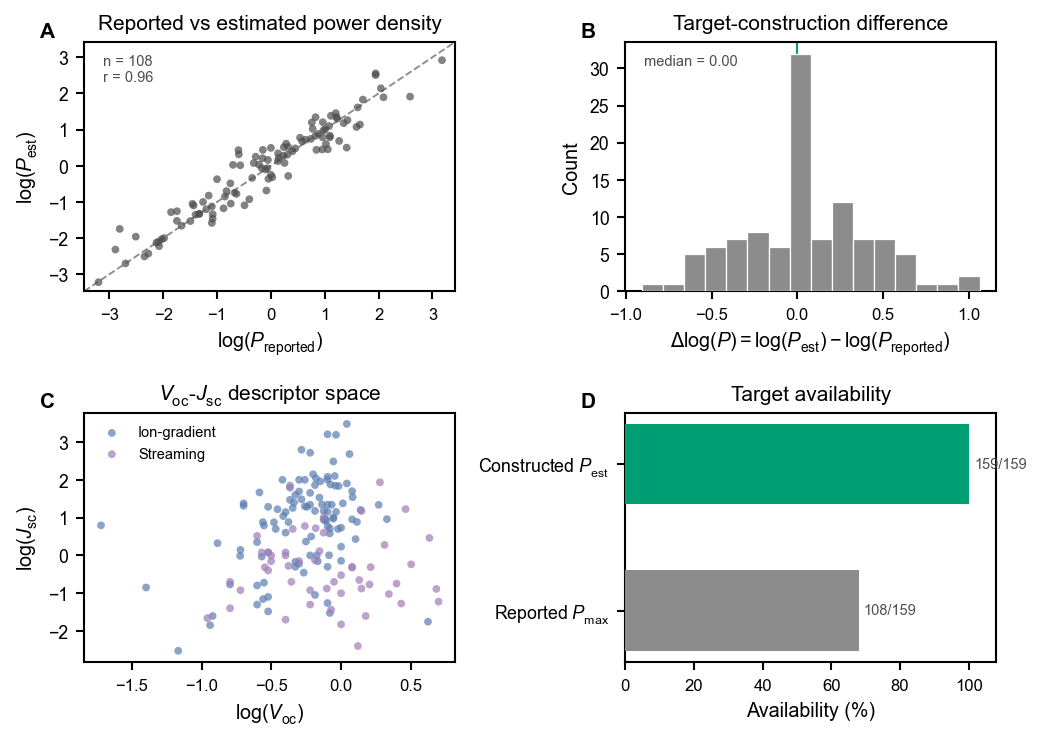

In [44]:
# ============================================================
# Fig. S1. Target construction and reported-power consistency
# Revised version: replace old Panel D with target availability
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.0))
axes = axes.flatten()

# ------------------------------------------------------------
# A. Reported vs estimated power density
# ------------------------------------------------------------
ax = axes[0]

x = figS1_both_power["log_P_reported"]
y = figS1_both_power["log_P_est"]

ax.scatter(
    x,
    y,
    s=SCATTER_SIZE,
    alpha=SCATTER_ALPHA,
    color=COLORS["dark_gray"],
    edgecolor="none",
    zorder=3,
)

xy_min = np.nanmin([x.min(), y.min()]) - 0.25
xy_max = np.nanmax([x.max(), y.max()]) + 0.25

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    ls="--",
    lw=0.9,
    color=COLORS["gray"],
    zorder=1,
)

r_value = np.corrcoef(x, y)[0, 1]

ax.text(
    0.05,
    0.95,
    f"n = {len(figS1_both_power)}\nr = {r_value:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=7,
    color=COLORS["dark_gray"],
)

ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)

ax.set_xlabel(r"$\log(P_{\mathrm{reported}})$")
ax.set_ylabel(r"$\log(P_{\mathrm{est}})$")
ax.set_title("Reported vs estimated power density")

format_ax(ax)
add_panel_label(ax, "A")


# ------------------------------------------------------------
# B. Difference between estimated and reported power
# ------------------------------------------------------------
ax = axes[1]

delta = figS1_both_power["delta_logP_est_minus_reported"].dropna()

ax.hist(
    delta,
    bins=16,
    color=COLORS["gray"],
    edgecolor="white",
    linewidth=0.6,
    zorder=3,
)

ax.axvline(
    0,
    color=COLORS["dark_gray"],
    lw=0.9,
    ls="--",
    zorder=1,
)

median_delta = np.nanmedian(delta)

ax.axvline(
    median_delta,
    color=REGIME_COLORS["low_R"],
    lw=1.0,
    ls="-",
    zorder=2,
)

ax.text(
    0.05,
    0.95,
    f"median = {median_delta:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=7,
    color=COLORS["dark_gray"],
)

ax.set_xlabel(
    r"$\Delta \log(P)=\log(P_{\mathrm{est}})-\log(P_{\mathrm{reported}})$"
)
ax.set_ylabel("Count")
ax.set_title("Target-construction difference")

format_ax(ax)
add_panel_label(ax, "B")


# ------------------------------------------------------------
# C. Voc-Jsc descriptor space
# ------------------------------------------------------------
ax = axes[2]

mechanism_order = ["ion_gradient", "streaming"]
mechanism_label_map = {
    "ion_gradient": "Ion-gradient",
    "streaming": "Streaming",
}

for mech in mechanism_order:
    sub = figS1_vj.loc[figS1_vj["mechanism"] == mech].copy()
    if len(sub) == 0:
        continue

    ax.scatter(
        sub["log_Voc"],
        sub["log_Jsc"],
        s=SCATTER_SIZE,
        alpha=SCATTER_ALPHA,
        color=DESCRIPTOR_COLORS.get(mech, COLORS["gray"]),
        edgecolor="none",
        label=mechanism_label_map.get(mech, clean_label_for_plot(mech)),
        zorder=3,
    )

other = figS1_vj.loc[~figS1_vj["mechanism"].isin(mechanism_order)].copy()

if len(other) > 0:
    ax.scatter(
        other["log_Voc"],
        other["log_Jsc"],
        s=SCATTER_SIZE,
        alpha=SCATTER_ALPHA,
        color=COLORS["gray"],
        edgecolor="none",
        label="Other",
        zorder=3,
    )

ax.set_xlabel(r"$\log(V_{\mathrm{oc}})$")
ax.set_ylabel(r"$\log(J_{\mathrm{sc}})$")
ax.set_title(r"$V_{\mathrm{oc}}$-$J_{\mathrm{sc}}$ descriptor space")
ax.legend(frameon=False, fontsize=7, loc="best")

format_ax(ax)
add_panel_label(ax, "C")


# ------------------------------------------------------------
# D. Target availability comparison
# ------------------------------------------------------------
ax = axes[3]

availability_df = pd.DataFrame(
    {
        "target": [
            r"Reported $P_{\mathrm{max}}$",
            r"Constructed $P_{\mathrm{est}}$",
        ],
        "n_available": [
            figS1_df["P_reported_uW_cm2"].where(figS1_df["P_reported_uW_cm2"] > 0).notna().sum(),
            figS1_df["log_P_est"].notna().sum(),
        ],
    }
)

availability_df["n_total"] = len(figS1_df)
availability_df["availability_percent"] = (
    100 * availability_df["n_available"] / availability_df["n_total"]
)

colors = [
    COLORS["gray"],
    REGIME_COLORS["low_R"],
]

ypos = np.arange(len(availability_df))

ax.barh(
    ypos,
    availability_df["availability_percent"],
    color=colors,
    edgecolor="none",
    height=0.55,
    zorder=3,
)

for i, row in availability_df.iterrows():
    ax.text(
        row["availability_percent"] + 1.5,
        i,
        f"{int(row['n_available'])}/{int(row['n_total'])}",
        va="center",
        ha="left",
        fontsize=7,
        color=COLORS["dark_gray"],
    )

ax.set_yticks(ypos)
ax.set_yticklabels(availability_df["target"])
ax.set_xlim(0, 108)
ax.set_xlabel("Availability (%)")
ax.set_title("Target availability")

format_ax(ax)
add_panel_label(ax, "D")


plt.tight_layout(w_pad=1.3, h_pad=1.4)

save_combined_figure(
    fig,
    "Fig_S1",
    "Fig_S1_target_construction_reported_power_consistency"
)

plt.show()

Saved:
 - results\supporting_materials\figures\Fig_S2\Fig_S2_model_validation_robustness_diagnostics.pdf
 - results\supporting_materials\figures\Fig_S2\Fig_S2_model_validation_robustness_diagnostics.svg
 - results\supporting_materials\figures\Fig_S2\Fig_S2_model_validation_robustness_diagnostics.png


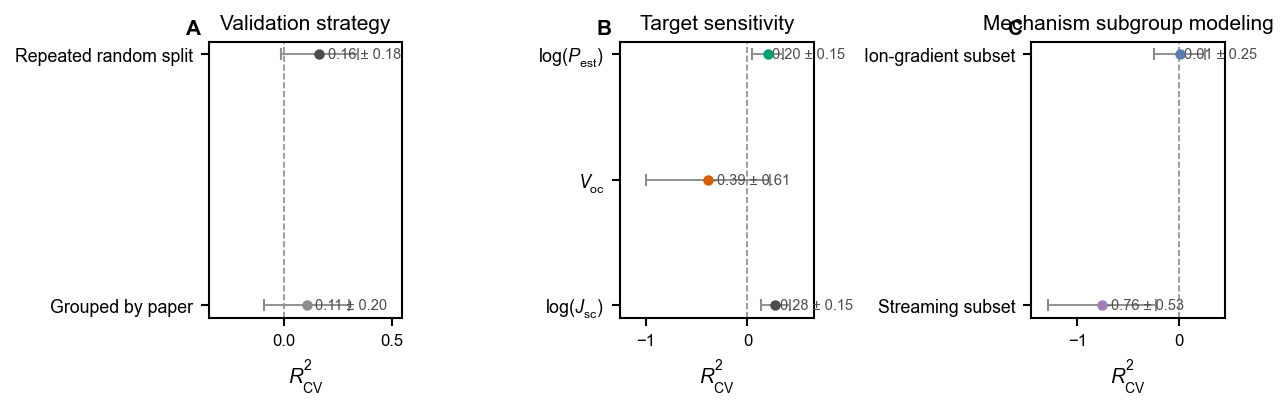

In [45]:
# ============================================================
# Fig. S2. Model validation and robustness diagnostics
# This figure supplements Fig. 3 without repeating model comparison,
# feature ablation, or SHAP ranking.
# ============================================================

# ------------------------------------------------------------
# 1. Robustness summary values
# These values are summarized from 05_modeling_phase2_robustness.ipynb.
# ------------------------------------------------------------

figS2_validation_df = pd.DataFrame(
    {
        "validation_setting": [
            "Repeated random split",
            "Grouped by paper",
        ],
        "R2_CV_mean": [
            0.164,
            0.106,
        ],
        "R2_CV_std": [
            0.179,
            0.198,
        ],
    }
)

figS2_target_df = pd.DataFrame(
    {
        "target": [
            r"$\log(P_{\mathrm{est}})$",
            r"$V_{\mathrm{oc}}$",
            r"$\log(J_{\mathrm{sc}})$",
        ],
        "R2_CV_mean": [
            0.197,
            -0.386,
            0.275,
        ],
        "R2_CV_std": [
            0.155,
            0.607,
            0.146,
        ],
    }
)

figS2_subgroup_df = pd.DataFrame(
    {
        "subgroup": [
            "Ion-gradient subset",
            "Streaming subset",
        ],
        "R2_CV_mean": [
            0.005,
            -0.757,
        ],
        "R2_CV_std": [
            0.247,
            0.530,
        ],
    }
)

# Save plotting data for reproducibility
figS2_out_dir = SI_FIG_DIR / "Fig_S2"
figS2_out_dir.mkdir(parents=True, exist_ok=True)

figS2_validation_df.to_csv(
    figS2_out_dir / "Fig_S2A_validation_strategy_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

figS2_target_df.to_csv(
    figS2_out_dir / "Fig_S2B_target_sensitivity_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

figS2_subgroup_df.to_csv(
    figS2_out_dir / "Fig_S2C_mechanism_subgroup_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

# ------------------------------------------------------------
# 2. Plot helper for horizontal mean ± std R2 plots
# ------------------------------------------------------------

def plot_horizontal_r2_errorbar(
    ax,
    df,
    label_col,
    mean_col="R2_CV_mean",
    std_col="R2_CV_std",
    colors=None,
    xlim=(-1.0, 0.6),
    xlabel=r"$R^2_{\mathrm{CV}}$",
):
    plot_df = df.copy()
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    y = np.arange(len(plot_df))

    if colors is None:
        colors = [COLORS["dark_gray"]] * len(plot_df)
    else:
        colors = colors[::-1]

    ax.axvline(
        0,
        color=COLORS["gray"],
        lw=0.8,
        ls="--",
        zorder=1,
    )

    for i, row in plot_df.iterrows():
        ax.errorbar(
            row[mean_col],
            i,
            xerr=row[std_col],
            fmt="o",
            color=colors[i],
            ecolor=COLORS["gray"],
            elinewidth=0.9,
            capsize=3,
            markersize=4,
            zorder=3,
        )

        ax.text(
            row[mean_col] + 0.04,
            i,
            f"{row[mean_col]:.2f} ± {row[std_col]:.2f}",
            va="center",
            ha="left",
            fontsize=7,
            color=COLORS["dark_gray"],
        )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df[label_col])
    ax.set_xlim(xlim)
    ax.set_xlabel(xlabel)

    format_ax(ax)


# ------------------------------------------------------------
# 3. Combined Fig. S2
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.8))

# A. Validation strategy
validation_colors = [
    COLORS["dark_gray"],
    COLORS["gray"],
]

plot_horizontal_r2_errorbar(
    axes[0],
    figS2_validation_df,
    label_col="validation_setting",
    colors=validation_colors,
    xlim=(-0.35, 0.55),
)

axes[0].set_title("Validation strategy")
add_panel_label(axes[0], "A")


# B. Target sensitivity
target_colors = [
    REGIME_COLORS["low_R"],   # main target
    REGIME_COLORS["high_R"],  # poor Voc prediction
    COLORS["dark_gray"],      # log(Jsc)
]

plot_horizontal_r2_errorbar(
    axes[1],
    figS2_target_df,
    label_col="target",
    colors=target_colors,
    xlim=(-1.25, 0.65),
)

axes[1].set_title("Target sensitivity")
add_panel_label(axes[1], "B")


# C. Mechanism subgroup modeling
subgroup_colors = [
    DESCRIPTOR_COLORS.get("ion_gradient", COLORS["gray"]),
    DESCRIPTOR_COLORS.get("streaming", COLORS["gray"]),
]

plot_horizontal_r2_errorbar(
    axes[2],
    figS2_subgroup_df,
    label_col="subgroup",
    colors=subgroup_colors,
    xlim=(-1.45, 0.45),
)

axes[2].set_title("Mechanism subgroup modeling")
add_panel_label(axes[2], "C")


plt.tight_layout(w_pad=1.6)

save_combined_figure(
    fig,
    "Fig_S2",
    "Fig_S2_model_validation_robustness_diagnostics"
)

plt.show()

Observed-R subset for threshold sensitivity:
(112, 2)
Closest swept threshold to final threshold:


,threshold_log_R,n_low_R,n_high_R,median_low_R,median_high_R,median_separation_low_minus_high,mean_separation_low_minus_high,R2_CV_mean_regime_only,R2_CV_std_regime_only
16,-0.980618,55.0,57.0,0.454845,-0.823906,1.278751,1.263644,0.192013,0.084727


Saved:
 - results\supporting_materials\figures\Fig_S3\Fig_S3_R_regime_threshold_sensitivity.pdf
 - results\supporting_materials\figures\Fig_S3\Fig_S3_R_regime_threshold_sensitivity.svg
 - results\supporting_materials\figures\Fig_S3\Fig_S3_R_regime_threshold_sensitivity.png


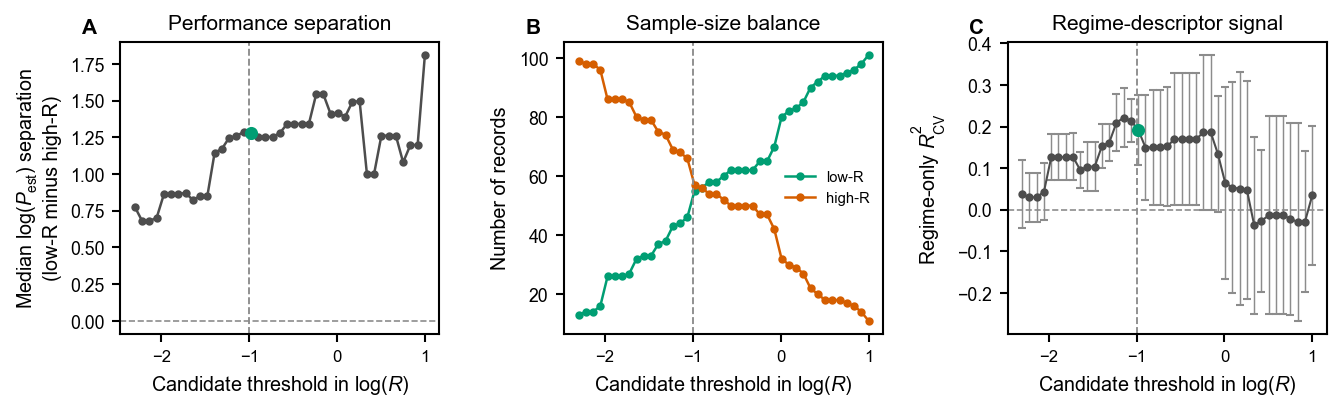

In [46]:
# ============================================================
# Fig. S3. Resistance-regime threshold sensitivity
# This figure supports the choice of log(R) = -1 without
# repeating the main-text Fig. 4 scatter/boxplot.
# ============================================================

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# ------------------------------------------------------------
# 1. Prepare observed-R subset
# ------------------------------------------------------------

figS3_raw = source_data["fig4_logR_raw"].copy()

col_logR = pick_col(
    figS3_raw,
    ["log_R", "log_internal_resistance_Mohm", "log_internal_resistance"],
    contains=["log"],
)

col_logP = pick_col(
    figS3_raw,
    ["log_P_est", "log_estimated_power_density", "log_power"],
    contains=["log"],
)

if col_logR is None or col_logP is None:
    print("Available columns:")
    print(figS3_raw.columns.tolist())
    raise ValueError("Could not identify log(R) or log(P_est) columns.")

figS3_df = figS3_raw[[col_logR, col_logP]].copy()
figS3_df = figS3_df.rename(
    columns={
        col_logR: "log_R",
        col_logP: "log_P_est",
    }
)

figS3_df["log_R"] = pd.to_numeric(figS3_df["log_R"], errors="coerce")
figS3_df["log_P_est"] = pd.to_numeric(figS3_df["log_P_est"], errors="coerce")
figS3_df = figS3_df.dropna(subset=["log_R", "log_P_est"]).copy()

print("Observed-R subset for threshold sensitivity:")
print(figS3_df.shape)

# ------------------------------------------------------------
# 2. Sweep candidate thresholds
# ------------------------------------------------------------

# Use a central quantile range to avoid extremely imbalanced splits
q_low, q_high = figS3_df["log_R"].quantile([0.10, 0.90])
candidate_thresholds = np.linspace(q_low, q_high, 41)

threshold_rows = []

for thr in candidate_thresholds:
    low_mask = figS3_df["log_R"] <= thr
    high_mask = figS3_df["log_R"] > thr

    n_low = int(low_mask.sum())
    n_high = int(high_mask.sum())

    # Avoid very small groups
    if n_low < 8 or n_high < 8:
        continue

    low_vals = figS3_df.loc[low_mask, "log_P_est"]
    high_vals = figS3_df.loc[high_mask, "log_P_est"]

    median_low = low_vals.median()
    median_high = high_vals.median()
    mean_low = low_vals.mean()
    mean_high = high_vals.mean()

    median_separation = median_low - median_high
    mean_separation = mean_low - mean_high

    # Simple regime-only model:
    # X = 1 for low-R, 0 for high-R
    X = low_mask.astype(int).values.reshape(-1, 1)
    y = figS3_df["log_P_est"].values

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    model = LinearRegression()

    cv_scores = cross_val_score(
        model,
        X,
        y,
        scoring="r2",
        cv=cv,
    )

    threshold_rows.append(
        {
            "threshold_log_R": thr,
            "n_low_R": n_low,
            "n_high_R": n_high,
            "median_low_R": median_low,
            "median_high_R": median_high,
            "median_separation_low_minus_high": median_separation,
            "mean_separation_low_minus_high": mean_separation,
            "R2_CV_mean_regime_only": np.mean(cv_scores),
            "R2_CV_std_regime_only": np.std(cv_scores),
        }
    )

figS3_threshold_df = pd.DataFrame(threshold_rows)

# Add final threshold row information
final_threshold = R_THRESHOLD

final_row = figS3_threshold_df.iloc[
    (figS3_threshold_df["threshold_log_R"] - final_threshold).abs().argmin()
]

print("Closest swept threshold to final threshold:")
display(final_row.to_frame().T)

# Save plotting data
figS3_out_dir = SI_FIG_DIR / "Fig_S3"
figS3_out_dir.mkdir(parents=True, exist_ok=True)

figS3_threshold_df.to_csv(
    figS3_out_dir / "Fig_S3_threshold_sensitivity_data.csv",
    index=False,
    encoding="utf-8-sig",
)

# ------------------------------------------------------------
# 3. Plot combined Fig. S3
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(9.0, 2.8))

# ------------------------------------------------------------
# A. Median performance separation
# ------------------------------------------------------------
ax = axes[0]

ax.plot(
    figS3_threshold_df["threshold_log_R"],
    figS3_threshold_df["median_separation_low_minus_high"],
    color=COLORS["dark_gray"],
    lw=1.2,
    marker="o",
    markersize=3,
)

ax.axvline(
    final_threshold,
    color=REGIME_COLORS["threshold"],
    lw=0.9,
    ls="--",
)

ax.axhline(
    0,
    color=COLORS["gray"],
    lw=0.8,
    ls="--",
)

ax.scatter(
    final_row["threshold_log_R"],
    final_row["median_separation_low_minus_high"],
    color=REGIME_COLORS["low_R"],
    s=28,
    zorder=4,
)

ax.set_xlabel(r"Candidate threshold in $\log(R)$")
ax.set_ylabel(
    r"Median $\log(P_{\mathrm{est}})$ separation"
    "\n"
    r"(low-R minus high-R)"
)
ax.set_title("Performance separation")

format_ax(ax)
add_panel_label(ax, "A")


# ------------------------------------------------------------
# B. Sample-size balance
# ------------------------------------------------------------
ax = axes[1]

ax.plot(
    figS3_threshold_df["threshold_log_R"],
    figS3_threshold_df["n_low_R"],
    color=REGIME_COLORS["low_R"],
    lw=1.2,
    marker="o",
    markersize=3,
    label="low-R",
)

ax.plot(
    figS3_threshold_df["threshold_log_R"],
    figS3_threshold_df["n_high_R"],
    color=REGIME_COLORS["high_R"],
    lw=1.2,
    marker="o",
    markersize=3,
    label="high-R",
)

ax.axvline(
    final_threshold,
    color=REGIME_COLORS["threshold"],
    lw=0.9,
    ls="--",
)

ax.set_xlabel(r"Candidate threshold in $\log(R)$")
ax.set_ylabel("Number of records")
ax.set_title("Sample-size balance")
ax.legend(frameon=False, fontsize=7, loc="best")

format_ax(ax)
add_panel_label(ax, "B")


# ------------------------------------------------------------
# C. Regime-only descriptor performance
# ------------------------------------------------------------
ax = axes[2]

ax.errorbar(
    figS3_threshold_df["threshold_log_R"],
    figS3_threshold_df["R2_CV_mean_regime_only"],
    yerr=figS3_threshold_df["R2_CV_std_regime_only"],
    fmt="o-",
    color=COLORS["dark_gray"],
    ecolor=COLORS["gray"],
    elinewidth=0.7,
    capsize=2,
    markersize=3,
    lw=1.0,
    zorder=3,
)

ax.axvline(
    final_threshold,
    color=REGIME_COLORS["threshold"],
    lw=0.9,
    ls="--",
)

ax.axhline(
    0,
    color=COLORS["gray"],
    lw=0.8,
    ls="--",
)

ax.scatter(
    final_row["threshold_log_R"],
    final_row["R2_CV_mean_regime_only"],
    color=REGIME_COLORS["low_R"],
    s=28,
    zorder=4,
)

ax.set_xlabel(r"Candidate threshold in $\log(R)$")
ax.set_ylabel(r"Regime-only $R^2_{\mathrm{CV}}$")
ax.set_title("Regime-descriptor signal")

format_ax(ax)
add_panel_label(ax, "C")


plt.tight_layout(w_pad=1.5)

save_combined_figure(
    fig,
    "Fig_S3",
    "Fig_S3_R_regime_threshold_sensitivity"
)

plt.show()

In [47]:
# ============================================================
# Fig. S4 data preparation
# Extended internal-resistance origin analysis
# ============================================================

# Find log(R)
col_logR = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["log", "resistance"],
        ["log_r"],
        ["logr"],
    ],
)

# If log(R) is not available, compute it from internal resistance
if col_logR is None:
    col_R = find_col_by_keywords(
        df_full,
        keyword_groups=[
            ["internal", "resistance"],
            ["resistance"],
        ],
        exclude_keywords=["log"],
    )
    if col_R is None:
        raise ValueError("Cannot find internal resistance column.")
        
    df_full["log_R_for_S4"] = np.log10(
        pd.to_numeric(df_full[col_R], errors="coerce").where(
            pd.to_numeric(df_full[col_R], errors="coerce") > 0
        )
    )
    col_logR = "log_R_for_S4"

# Descriptor columns
col_ion_S4 = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["ion_type"],
        ["ion", "type"],
    ],
)

col_structure_S4 = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["structure_class"],
        ["structure"],
    ],
)

col_electrolyte_S4 = find_col_by_keywords(
    df_full,
    keyword_groups=[
        ["inorganic", "electrolyte"],
        ["electrolyte", "present"],
        ["electrolyte"],
    ],
)

# Optional detailed ion column
specific_ion_options = [
    "primary_mobile_ion",
    "mobile_ion",
    "ion_species",
    "specific_ion",
    "salt_cation",
    "cation_type",
    "cation",
]

col_specific_ion_S4 = None
for c in specific_ion_options:
    if c in df_full.columns:
        if df_full[c].dropna().astype(str).nunique() >= 3:
            col_specific_ion_S4 = c
            break

if col_specific_ion_S4 is None:
    col_specific_ion_S4 = col_ion_S4

print("Columns used for Fig. S4:")
print("log(R):", col_logR)
print("ion type:", col_ion_S4)
print("structure:", col_structure_S4)
print("electrolyte:", col_electrolyte_S4)
print("specific/mobile ion:", col_specific_ion_S4)

if col_ion_S4 is None or col_structure_S4 is None or col_electrolyte_S4 is None:
    raise ValueError("Missing one or more descriptor columns for Fig. S4.")

def normalize_electrolyte(x):
    s = str(x).strip().lower()
    
    if s in ["1", "1.0", "yes", "true", "with", "present", "with_inorganic_electrolyte"]:
        return "with electrolyte"
    if s in ["0", "0.0", "no", "false", "without", "absent", "without_inorganic_electrolyte"]:
        return "without electrolyte"
    if "without" in s or "absent" in s:
        return "without electrolyte"
    if "with" in s or "present" in s:
        return "with electrolyte"
    
    return str(x)

figS4_df = pd.DataFrame({
    "log_R": pd.to_numeric(df_full[col_logR], errors="coerce"),
    "ion_type": df_full[col_ion_S4].astype(str),
    "structure": df_full[col_structure_S4].astype(str),
    "electrolyte": df_full[col_electrolyte_S4].apply(normalize_electrolyte),
    "specific_ion": df_full[col_specific_ion_S4].astype(str),
})

figS4_df = figS4_df.dropna(subset=["log_R", "ion_type", "structure", "electrolyte"]).copy()

print("Fig. S4 observed-R records:", figS4_df.shape[0])
display(figS4_df.head())

# Save plotting data
figS4_out_dir = SI_FIG_DIR / "Fig_S4"
figS4_out_dir.mkdir(parents=True, exist_ok=True)

figS4_df.to_csv(
    figS4_out_dir / "Fig_S4_extended_R_origin_plotting_data.csv",
    index=False,
    encoding="utf-8-sig",
)

Columns used for Fig. S4:
log(R): log_internal_resistance_Mohm
ion type: ion_type
structure: structure_class
electrolyte: inorganic_electrolyte_present
specific/mobile ion: primary_mobile_ion
Fig. S4 observed-R records: 112


,log_R,ion_type,structure,electrolyte,specific_ion
0,0.903090,proton,porous,without electrolyte,H+
1,1.535294,anion,porous,without electrolyte,OH-
2,1.778151,anion,porous,without electrolyte,OH-
5,0.301030,proton,porous,without electrolyte,H+
11,0.301030,proton,porous,without electrolyte,H+


Saved:
 - results\supporting_materials\figures\Fig_S4\Fig_S4_extended_internal_resistance_origin_analysis.pdf
 - results\supporting_materials\figures\Fig_S4\Fig_S4_extended_internal_resistance_origin_analysis.svg
 - results\supporting_materials\figures\Fig_S4\Fig_S4_extended_internal_resistance_origin_analysis.png


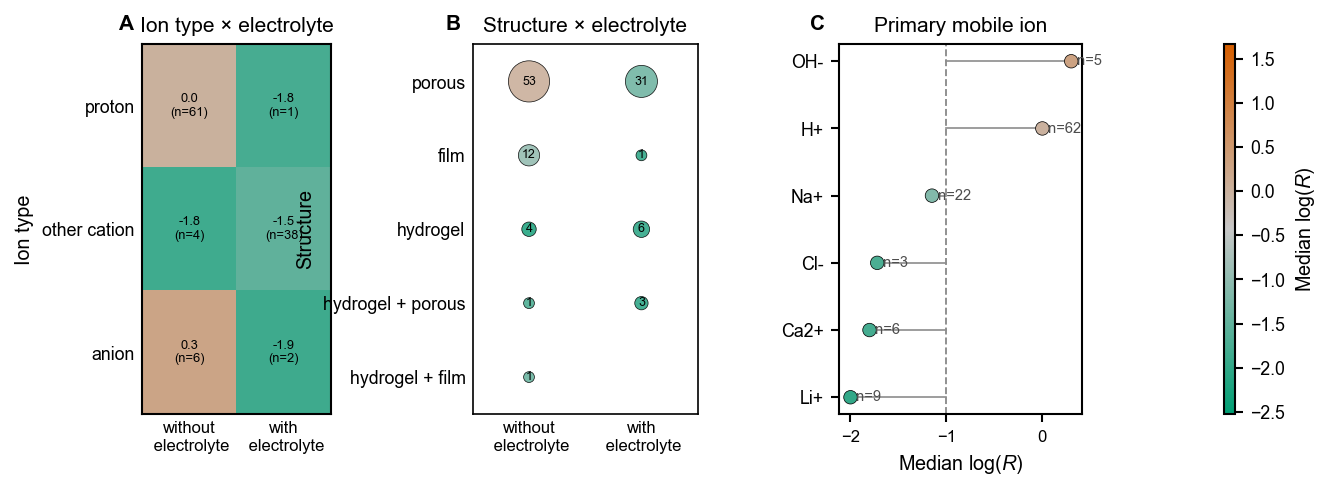

In [49]:
# ============================================================
# Fig. S4. Extended internal-resistance origin analysis
# Revised: A heatmap, B bubble map, C dot/lollipop plot
# ============================================================

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# ---------- shared color scale ----------
R_CMAP = LinearSegmentedColormap.from_list(
    "R_origin_cmap",
    [
        REGIME_COLORS["low_R"],
        COLORS["light_gray"],
        REGIME_COLORS["high_R"],
    ],
)

r_vmin = np.nanpercentile(figS4_df["log_R"], 5)
r_vmax = np.nanpercentile(figS4_df["log_R"], 95)
r_norm = Normalize(vmin=r_vmin, vmax=r_vmax)
sm = ScalarMappable(norm=r_norm, cmap=R_CMAP)
sm.set_array([])


def short_label_s4(x):
    x = str(x)
    x = x.replace("_", " ")
    x = x.replace("without electrolyte", "without\n electrolyte")
    x = x.replace("with electrolyte", "with\n electrolyte")
    return x


# ---------- Panel A data: ion type × electrolyte heatmap ----------
ion_order = ["proton", "other_cation", "anion"]
ion_order = [x for x in ion_order if x in figS4_df["ion_type"].unique()]

electrolyte_order = ["without electrolyte", "with electrolyte"]
electrolyte_order = [x for x in electrolyte_order if x in figS4_df["electrolyte"].unique()]

med_ion = figS4_df.pivot_table(
    index="ion_type",
    columns="electrolyte",
    values="log_R",
    aggfunc="median",
).reindex(index=ion_order, columns=electrolyte_order)

cnt_ion = figS4_df.pivot_table(
    index="ion_type",
    columns="electrolyte",
    values="log_R",
    aggfunc="count",
).reindex(index=ion_order, columns=electrolyte_order)


# ---------- Panel B data: structure × electrolyte bubble map ----------
structure_order = [
    "porous",
    "film",
    "hydrogel",
    "hydrogel + porous",
    "hydrogel + film",
]
structure_order = [x for x in structure_order if x in figS4_df["structure"].unique()]

bubble_df = (
    figS4_df
    .groupby(["structure", "electrolyte"])
    .agg(
        n=("log_R", "count"),
        median_log_R=("log_R", "median"),
    )
    .reset_index()
)

bubble_df["x"] = bubble_df["electrolyte"].map({v: i for i, v in enumerate(electrolyte_order)})
bubble_df["y"] = bubble_df["structure"].map({v: i for i, v in enumerate(structure_order)})
bubble_df = bubble_df.dropna(subset=["x", "y"]).copy()


# ---------- Panel C data: primary mobile ion dot plot ----------
ion_summary = (
    figS4_df
    .groupby("specific_ion")
    .agg(
        n=("log_R", "count"),
        median_log_R=("log_R", "median"),
    )
    .reset_index()
)

ion_summary = ion_summary.loc[
    ~ion_summary["specific_ion"].astype(str).str.lower().isin(["nan", "unknown", "none"])
].copy()

ion_summary = ion_summary.loc[ion_summary["n"] >= 3].copy()
ion_summary = ion_summary.sort_values("median_log_R", ascending=True)


# ---------- Save summary data ----------
figS4_out_dir = SI_FIG_DIR / "Fig_S4"
figS4_out_dir.mkdir(parents=True, exist_ok=True)

med_ion.to_csv(
    figS4_out_dir / "Fig_S4A_ion_electrolyte_median_logR.csv",
    encoding="utf-8-sig",
)

bubble_df.to_csv(
    figS4_out_dir / "Fig_S4B_structure_electrolyte_bubble_data.csv",
    index=False,
    encoding="utf-8-sig",
)

ion_summary.to_csv(
    figS4_out_dir / "Fig_S4C_primary_mobile_ion_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


# ---------- Plot ----------
fig = plt.figure(figsize=(9.4, 3.2))

gs = fig.add_gridspec(
    1,
    4,
    width_ratios=[1.05, 1.25, 1.35, 0.06],
    wspace=0.85,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])
cax = fig.add_subplot(gs[0, 3])


# ---------- A. ion type × electrolyte heatmap ----------
im = axA.imshow(
    med_ion.values,
    cmap=R_CMAP,
    norm=r_norm,
    aspect="auto",
)

axA.set_xticks(np.arange(len(med_ion.columns)))
axA.set_xticklabels([short_label_s4(x) for x in med_ion.columns])

axA.set_yticks(np.arange(len(med_ion.index)))
axA.set_yticklabels([short_label_s4(x) for x in med_ion.index])

for i in range(med_ion.shape[0]):
    for j in range(med_ion.shape[1]):
        value = med_ion.iloc[i, j]
        n = cnt_ion.iloc[i, j]
        if pd.notna(value):
            axA.text(
                j,
                i,
                f"{value:.1f}\n(n={int(n)})",
                ha="center",
                va="center",
                fontsize=6.2,
                color="black",
            )

axA.set_title("Ion type × electrolyte")
axA.set_ylabel("Ion type")
axA.tick_params(axis="both", length=0)
add_panel_label(axA, "A")


# ---------- B. structure × electrolyte bubble map ----------
sizes = 20 + 7 * bubble_df["n"]

axB.scatter(
    bubble_df["x"],
    bubble_df["y"],
    s=sizes,
    c=bubble_df["median_log_R"],
    cmap=R_CMAP,
    norm=r_norm,
    edgecolor="black",
    linewidth=0.35,
    alpha=0.90,
)

axB.set_xticks(np.arange(len(electrolyte_order)))
axB.set_xticklabels([short_label_s4(x) for x in electrolyte_order])

axB.set_yticks(np.arange(len(structure_order)))
axB.set_yticklabels([short_label_s4(x) for x in structure_order])

for _, row in bubble_df.iterrows():
    axB.text(
        row["x"],
        row["y"],
        str(int(row["n"])),
        ha="center",
        va="center",
        fontsize=6,
        color="black",
    )

axB.set_xlim(-0.5, len(electrolyte_order) - 0.5)
axB.set_ylim(-0.5, len(structure_order) - 0.5)
axB.invert_yaxis()

axB.set_title("Structure × electrolyte")
axB.set_ylabel("Structure")
axB.tick_params(axis="both", length=0)

for spine in axB.spines.values():
    spine.set_linewidth(0.8)

add_panel_label(axB, "B")


# ---------- C. primary mobile ion dot/lollipop plot ----------
y = np.arange(len(ion_summary))

axC.axvline(
    R_THRESHOLD,
    color=REGIME_COLORS["threshold"],
    lw=0.9,
    ls="--",
    zorder=1,
)

for i, (_, row) in enumerate(ion_summary.iterrows()):
    axC.plot(
        [R_THRESHOLD, row["median_log_R"]],
        [i, i],
        color=COLORS["gray"],
        lw=0.8,
        zorder=2,
    )

axC.scatter(
    ion_summary["median_log_R"],
    y,
    s=42,
    c=ion_summary["median_log_R"],
    cmap=R_CMAP,
    norm=r_norm,
    edgecolor="black",
    linewidth=0.35,
    zorder=3,
)

for i, (_, row) in enumerate(ion_summary.iterrows()):
    axC.text(
        row["median_log_R"] + 0.06,
        i,
        f"n={int(row['n'])}",
        va="center",
        ha="left",
        fontsize=7,
        color=COLORS["dark_gray"],
    )

axC.set_yticks(y)
axC.set_yticklabels([short_label_s4(x) for x in ion_summary["specific_ion"]])
axC.set_xlabel(r"Median $\log(R)$")
axC.set_title("Primary mobile ion")

format_ax(axC)
add_panel_label(axC, "C")


# ---------- Colorbar outside panels ----------
cbar = fig.colorbar(
    sm,
    cax=cax,
)

cbar.set_label(r"Median $\log(R)$")


save_combined_figure(
    fig,
    "Fig_S4",
    "Fig_S4_extended_internal_resistance_origin_analysis"
)

plt.show()

In [51]:
# ============================================================
# Fig. S5 data preparation
# Full virtual-design landscape
# ============================================================

figS5_raw = source_data["fig6_virtual_design"].copy()

print("Virtual design data shape:", figS5_raw.shape)
print("Columns:")
for c in figS5_raw.columns:
    print(" -", c)

# Identify columns
col_structure_S5 = pick_col(
    figS5_raw,
    ["structure_class", "structure"],
    contains=["structure"],
)

col_ion_S5 = pick_col(
    figS5_raw,
    ["ion_type", "ion"],
    contains=["ion"],
)

col_electrolyte_S5 = pick_col(
    figS5_raw,
    ["inorganic_electrolyte_present", "electrolyte", "inorganic_electrolyte"],
    contains=["electrolyte"],
)

col_logR_S5 = pick_col(
    figS5_raw,
    ["log_R", "log_internal_resistance", "logR"],
    contains=["log"],
)

col_pred_S5 = pick_col(
    figS5_raw,
    [
        "predicted_log_P_est",
        "predicted_log_estimated_power_density",
        "prediction",
        "predicted",
    ],
    contains=["pred"],
)

print("\nColumns used for Fig. S5:")
print("structure:", col_structure_S5)
print("ion:", col_ion_S5)
print("electrolyte:", col_electrolyte_S5)
print("log(R):", col_logR_S5)
print("prediction:", col_pred_S5)

if col_structure_S5 is None or col_logR_S5 is None or col_pred_S5 is None:
    raise ValueError("Missing required structure, log(R), or prediction column.")

def normalize_electrolyte_s5(x):
    s = str(x).strip().lower()
    if s in ["1", "1.0", "true", "yes", "with", "present", "with_inorganic_electrolyte"]:
        return "with electrolyte"
    if s in ["0", "0.0", "false", "no", "without", "absent", "without_inorganic_electrolyte"]:
        return "without electrolyte"
    if "without" in s or "absent" in s:
        return "without electrolyte"
    if "with" in s or "present" in s:
        return "with electrolyte"
    return str(x)

figS5_plot = pd.DataFrame({
    "structure": figS5_raw[col_structure_S5].astype(str),
    "log_R": pd.to_numeric(figS5_raw[col_logR_S5], errors="coerce"),
    "pred_log_P": pd.to_numeric(figS5_raw[col_pred_S5], errors="coerce"),
})

if col_ion_S5 is not None:
    figS5_plot["ion_type"] = figS5_raw[col_ion_S5].astype(str)
else:
    figS5_plot["ion_type"] = "not specified"

if col_electrolyte_S5 is not None:
    figS5_plot["electrolyte"] = figS5_raw[col_electrolyte_S5].apply(normalize_electrolyte_s5)
else:
    figS5_plot["electrolyte"] = "not specified"

figS5_plot = figS5_plot.dropna(subset=["structure", "ion_type", "electrolyte", "log_R", "pred_log_P"]).copy()

figS5_plot["design_label"] = (
    figS5_plot["structure"].str.replace("_", " ", regex=False)
    + " | "
    + figS5_plot["ion_type"].str.replace("_", " ", regex=False)
    + " | "
    + figS5_plot["electrolyte"].str.replace("_", " ", regex=False)
)

print("\nFig. S5 plotting data:")
print(figS5_plot.shape)
display(figS5_plot.head())

# Save plotting data
figS5_out_dir = SI_FIG_DIR / "Fig_S5"
figS5_out_dir.mkdir(parents=True, exist_ok=True)

figS5_plot.to_csv(
    figS5_out_dir / "Fig_S5_full_virtual_design_landscape_data.csv",
    index=False,
    encoding="utf-8-sig",
)

Virtual design data shape: (15, 5)
Columns:
 - structure_clean
 - structure_label
 - regime
 - log_R
 - predicted_log_P_est

Columns used for Fig. S5:
structure: structure_clean
ion: None
electrolyte: None
log(R): log_R
prediction: predicted_log_P_est

Fig. S5 plotting data:
(15, 6)


,structure,log_R,pred_log_P,ion_type,electrolyte,design_label
0,porous,-2.0,0.498885,not specified,not specified,porous | not specified | not specified
1,porous,-1.0,0.153324,not specified,not specified,porous | not specified | not specified
2,porous,0.0,-0.192238,not specified,not specified,porous | not specified | not specified
3,film,-2.0,1.794374,not specified,not specified,film | not specified | not specified
4,film,-1.0,1.448812,not specified,not specified,film | not specified | not specified


Saved:
 - results\supporting_materials\figures\Fig_S5\Fig_S5_full_virtual_design_landscape.pdf
 - results\supporting_materials\figures\Fig_S5\Fig_S5_full_virtual_design_landscape.svg
 - results\supporting_materials\figures\Fig_S5\Fig_S5_full_virtual_design_landscape.png


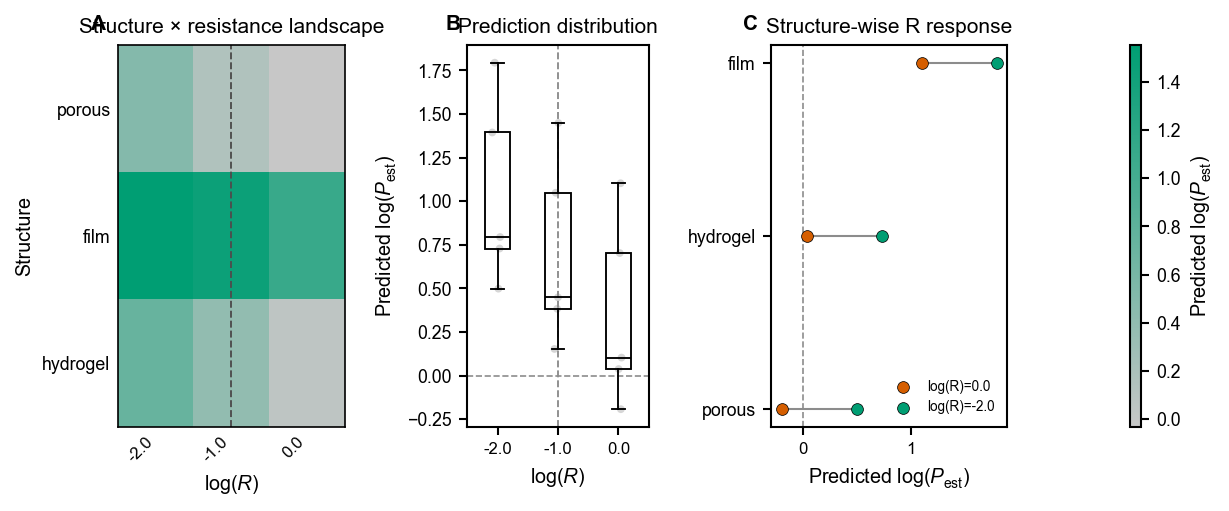

In [53]:
# ============================================================
# Fig. S5. Full virtual-design landscape
# Revised version:
# A. structure × log(R) heatmap
# B. prediction distribution across log(R)
# C. structure-wise predicted range across log(R)
# ============================================================

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# ------------------------------------------------------------
# 1. Structure × log(R) heatmap
# ------------------------------------------------------------

logR_values = sorted(figS5_plot["log_R"].dropna().unique().tolist())

structure_order = [
    "porous",
    "film",
    "hydrogel",
    "hydrogel + porous",
    "hydrogel + film",
]
structure_order = [x for x in structure_order if x in figS5_plot["structure"].unique()]

if len(structure_order) == 0:
    structure_order = sorted(figS5_plot["structure"].unique().tolist())

heatmap_df = figS5_plot.pivot_table(
    index="structure",
    columns="log_R",
    values="pred_log_P",
    aggfunc="median",
)

heatmap_df = heatmap_df.reindex(index=structure_order, columns=logR_values)

# ------------------------------------------------------------
# 2. Structure-wise range summary
# ------------------------------------------------------------

lowest_logR = min(logR_values)
highest_logR = max(logR_values)

range_rows = []

for structure in structure_order:
    sub = figS5_plot.loc[figS5_plot["structure"] == structure].copy()

    low_val = sub.loc[sub["log_R"] == lowest_logR, "pred_log_P"].median()
    high_val = sub.loc[sub["log_R"] == highest_logR, "pred_log_P"].median()
    mean_val = sub["pred_log_P"].mean()

    range_rows.append(
        {
            "structure": structure,
            "pred_at_lowest_logR": low_val,
            "pred_at_highest_logR": high_val,
            "mean_pred": mean_val,
        }
    )

range_df = pd.DataFrame(range_rows)
range_df = range_df.sort_values("mean_pred", ascending=True)

# Save data
figS5_out_dir = SI_FIG_DIR / "Fig_S5"
figS5_out_dir.mkdir(parents=True, exist_ok=True)

heatmap_df.to_csv(
    figS5_out_dir / "Fig_S5A_structure_logR_heatmap.csv",
    encoding="utf-8-sig",
)

range_df.to_csv(
    figS5_out_dir / "Fig_S5C_structure_predicted_range.csv",
    index=False,
    encoding="utf-8-sig",
)

# ------------------------------------------------------------
# 3. Color map
# ------------------------------------------------------------

P_CMAP = LinearSegmentedColormap.from_list(
    "virtual_design_performance_cmap",
    [
        COLORS["light_gray"],
        REGIME_COLORS["low_R"],
    ],
)

p_vmin = np.nanpercentile(figS5_plot["pred_log_P"], 5)
p_vmax = np.nanpercentile(figS5_plot["pred_log_P"], 95)

p_norm = Normalize(vmin=p_vmin, vmax=p_vmax)
p_mappable = ScalarMappable(norm=p_norm, cmap=P_CMAP)
p_mappable.set_array([])

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(8.8, 3.3))

gs = fig.add_gridspec(
    1,
    4,
    width_ratios=[1.25, 1.0, 1.30, 0.06],
    wspace=0.75,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])
cax = fig.add_subplot(gs[0, 3])

# ------------------------------------------------------------
# A. Structure × log(R) heatmap
# ------------------------------------------------------------

im = axA.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap=P_CMAP,
    norm=p_norm,
)

axA.set_xticks(np.arange(len(heatmap_df.columns)))
axA.set_xticklabels([f"{x:.1f}" for x in heatmap_df.columns], rotation=45, ha="right")

axA.set_yticks(np.arange(len(heatmap_df.index)))
axA.set_yticklabels([clean_label_for_plot(x) for x in heatmap_df.index])

axA.set_xlabel(r"$\log(R)$")
axA.set_ylabel("Structure")
axA.set_title("Structure × resistance landscape")

if R_THRESHOLD in heatmap_df.columns:
    thr_idx = list(heatmap_df.columns).index(R_THRESHOLD)
    axA.axvline(thr_idx, color=COLORS["dark_gray"], lw=0.9, ls="--")

axA.tick_params(axis="both", length=0)

for spine in axA.spines.values():
    spine.set_linewidth(0.8)

add_panel_label(axA, "A")

# ------------------------------------------------------------
# B. Predicted performance distribution across log(R)
# ------------------------------------------------------------

rng = np.random.default_rng(42)

for i, logR in enumerate(logR_values):
    sub = figS5_plot.loc[figS5_plot["log_R"] == logR, "pred_log_P"].dropna()

    x_jitter = rng.normal(i, 0.045, size=len(sub))

    axB.scatter(
        x_jitter,
        sub,
        s=SCATTER_SIZE,
        alpha=0.35,
        color=COLORS["gray"],
        edgecolor="none",
        zorder=2,
    )

    bp = axB.boxplot(
        [sub],
        positions=[i],
        widths=0.42,
        patch_artist=True,
        showfliers=False,
        zorder=3,
    )

    for patch in bp["boxes"]:
        patch.set_facecolor("none")
        patch.set_edgecolor(COLORS["black"])
        patch.set_linewidth(0.9)

    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color(COLORS["black"])
            line.set_linewidth(0.9)

if R_THRESHOLD in logR_values:
    thr_idx = logR_values.index(R_THRESHOLD)
    axB.axvline(thr_idx, color=REGIME_COLORS["threshold"], lw=0.9, ls="--")

axB.axhline(0, color=COLORS["gray"], lw=0.8, ls="--")

axB.set_xticks(np.arange(len(logR_values)))
axB.set_xticklabels([f"{x:.1f}" for x in logR_values])

axB.set_xlabel(r"$\log(R)$")
axB.set_ylabel(r"Predicted $\log(P_{\mathrm{est}})$")
axB.set_title("Prediction distribution")

format_ax(axB)
add_panel_label(axB, "B")

# ------------------------------------------------------------
# C. Structure-wise predicted range across log(R)
# ------------------------------------------------------------

y = np.arange(len(range_df))

for i, (_, row) in enumerate(range_df.iterrows()):
    axC.plot(
        [row["pred_at_highest_logR"], row["pred_at_lowest_logR"]],
        [i, i],
        color=COLORS["gray"],
        lw=1.0,
        zorder=1,
    )

axC.scatter(
    range_df["pred_at_highest_logR"],
    y,
    s=32,
    color=REGIME_COLORS["high_R"],
    edgecolor="black",
    linewidth=0.35,
    label=f"log(R)={highest_logR:.1f}",
    zorder=3,
)

axC.scatter(
    range_df["pred_at_lowest_logR"],
    y,
    s=32,
    color=REGIME_COLORS["low_R"],
    edgecolor="black",
    linewidth=0.35,
    label=f"log(R)={lowest_logR:.1f}",
    zorder=3,
)

axC.axvline(0, color=COLORS["gray"], lw=0.8, ls="--")

axC.set_yticks(y)
axC.set_yticklabels([clean_label_for_plot(x) for x in range_df["structure"]])

axC.set_xlabel(r"Predicted $\log(P_{\mathrm{est}})$")
axC.set_title("Structure-wise R response")
axC.legend(frameon=False, fontsize=6.5, loc="lower right")

format_ax(axC)
add_panel_label(axC, "C")

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    p_mappable,
    cax=cax,
)

cbar.set_label(r"Predicted $\log(P_{\mathrm{est}})$")

save_combined_figure(
    fig,
    "Fig_S5",
    "Fig_S5_full_virtual_design_landscape"
)

plt.show()